## Count table filtering and UMAP generation
Here I filter pancreatic islet SMARTseq processed count tables of different donors with and without T2D and generate UMAPs which are used to call cell types. 
This notebook includes data from the following datasets:
<ol>
  <li>libID: XIN - PMID: 27667665 - Dataset: GSE81608</li>
  <li>libID: WAN - PMID: 27364731 - Dataset: GSE83139</li>
  <li>libID: ENG - PMID: 28965763 - Dataset: GSE81547</li>
  <li>libID: SEG - PMID: 27667667 - Dataset: E-MTAB-5061</li>
  <li>libID: LAW - PMID: 27864352 - Dataset: GSE86469</li>
  <li>libID: LIJ - PMID: 26691212 - Dataset: GSE73727</li>
  <li>libID: CAM - PMID: 32302527 - Dataset: GSE124742</li>
  <li>libID: DAI - PMID: 35108513 - Dataset: GSE164875</li>
  <li>libID: LIU - PMID: 39763967 - Dataset: GSE270484</li>
  <li>libID: MAR - PMID: 35081145 - Dataset: HCA</li>
  <li>libID: HPA - PMID: NA       - Dataset: HPAP (Patchseq)</li>
  <li>libID: HPS - PMID: NA       - Dataset: HPAP (smartseq2)</li>
</ol>


In [1]:
import sys, os
import pandas as pd
import numpy as np
from pandas.io.parsers import read_csv
import matplotlib.pyplot as plt
import glob
import scanpy as sc
import scrublet as scr
import bbknn
import numpy as np
%matplotlib inline

# Import count_matrix
the count matrices are generated by counting of the reads falling in exons. I removed the INS-IGF2 gene from the GTF file to make it able to include the INS gene in our analysis. 

In [2]:
files = glob.glob('/Users/twanw/Documents/LUMC/projects/3UTRpancreas/Data_3UTR_project/revisions/1-counttables_v2/*.tsv') # count matrices
# threshold_vals = '/Users/twanw/Documents/LUMC/projects/3UTRpancreas/Data_3UTR_project/1-scRNA-seq/1-count_tables/filter_criteria_3utrcount.csv' # filtering criteria
# thv = read_csv(threshold_vals, sep=';', index_col=0)

In [3]:
# list of donor names from count matrix files
donors=[os.path.basename(f).strip('_count-matrix.tsv') for f in files]
donors

['HPA_HPAP-093',
 'HPA_HPAP-075',
 'HPS_HPAP-053',
 'DAI_H2280',
 'LAW_DonorM51',
 'HPA_HPAP-108',
 'SEG_HP1507101',
 'CAM_R247',
 'XIN_DonorND6',
 'HPA_HPAP-054',
 'CAM_R253',
 'DAI_AGJU173',
 'HPS_HPAP-058',
 'CAM_R229',
 'HPS_HPAP-079',
 'XIN_DonorT2D2',
 'MAR_R297',
 'WAN_AAJF122',
 'HPA_HPAP-065',
 'HPA_HPAP-083',
 'XIN_DonorT2D6',
 'XIN_DonorND9',
 'HPS_HPAP-121',
 'LIU_R366',
 'DAI_R335',
 'CAM_R257',
 'CAM_R269',
 'HPS_HPAP-062',
 'CAM_R243',
 'HPS_HPAP-090',
 'XIN_DonorND2',
 'HPS_HPAP-057',
 'CAM_R239',
 'LAW_DonorM30',
 'HPA_HPAP-097',
 'LIU_R372',
 'CAM_R262',
 'XIN_DonorND7',
 'CAM_R246',
 'SEG_HP1508501T2D',
 'CAM_R259',
 'LAW_DonorF55',
 'HPS_HPAP-052',
 'HPA_HPAP-074',
 'SEG_HP1506401',
 'CAM_R177',
 'ENG_DonorM22',
 'HPS_HPAP-124',
 'DAI_AGAH468',
 'XIN_DonorT2D3',
 'HPS_HPAP-059',
 'CAM_R237',
 'HPS_HPAP-081',
 'SEG_HP1504901',
 'ENG_DonorF38',
 'CAM_R252',
 'HPS_HPAP-063',
 'SEG_HP1502401',
 'CAM_R233',
 'CAM_R256',
 'WAN_ACAP236',
 'HPA_HPAP-106',
 'LIU_R367',
 'SEG

In [4]:
# number of donors in this analysis
len(donors)

149

# Filter count matrix

In [5]:
# Dictionary with unfiltered count tables
donor_matrices = dict()
for i in range(len(files)):
    donor_matrices[donors[i]] = read_csv(files[i], sep='\t', index_col=0)

In [6]:
min_reads = 10**4
mito_frac = 0.25

thv = pd.DataFrame(index=donors)
thv['min_reads'] = [min_reads for _ in range(len(donors))]
thv['mito_frac'] = [mito_frac for _ in range(len(donors))]

In [7]:
# table with filtering criteria 
thv

,min_reads,mito_frac
HPA_HPAP-093,10000,0.25
HPA_HPAP-075,10000,0.25
HPS_HPAP-053,10000,0.25
DAI_H2280,10000,0.25
LAW_DonorM51,10000,0.25
...,...,...
LIU_R365,10000,0.25
DAI_R336,10000,0.25
WAN_HP15041,10000,0.25
HPA_HPAP-079,10000,0.25


In [8]:
# dictionary with metadata, needed for selection
meta_dict = dict()
for key in donors:
    mito = [idx for idx in donor_matrices[key].index if 'MT-' in idx]
    matrix = donor_matrices[key].loc[mito]
    meta_dict[key] = pd.DataFrame({'reads': donor_matrices[key].sum(), 'genes': (donor_matrices[key]>0).sum()})
    meta_dict[key]['mito'] = matrix.loc[mito].sum()
#     meta_dict[key]['GAPDH'] = donor_matrices[key].loc['GAPDH>12']
#     meta_dict[key]['GAPDH_frac'] = meta_dict[key]['GAPDH'] /meta_dict[key]['reads']
    meta_dict[key]['mito_frac'] = meta_dict[key]['mito']/meta_dict[key]['reads']

In [9]:
# meta data df check
meta_dict['XIN_DonorT2D2']

,reads,genes,mito,mito_frac
XIN_DonorT2D2_Cell1199,716471,6616,32668,0.045596
XIN_DonorT2D2_Cell1200,1427251,5559,43720,0.030632
XIN_DonorT2D2_Cell1201,895007,6638,27051,0.030224
XIN_DonorT2D2_Cell1202,1486644,5617,129064,0.086816
XIN_DonorT2D2_Cell1203,1247407,7205,48238,0.038671
...,...,...,...,...
XIN_DonorT2D2_Cell970,6417460,5529,357852,0.055762
XIN_DonorT2D2_Cell971,1915883,6488,71028,0.037073
XIN_DonorT2D2_Cell972,1512140,7046,285651,0.188905
XIN_DonorT2D2_Cell973,1384615,6428,108336,0.078243


In [10]:
# dictionary with filtered metadata, based on values of thv table
# 1) filter on minimal amount of reads
# 2) filter on maximum of mitochondrial gene fraction
# 3) filter cells with more than 200 genes
mingenes=200

filtered_meta_dict = dict()
for key in donors:
    filtered_meta_dict[key] = meta_dict[key][(meta_dict[key]['reads']> thv.loc[key,'min_reads']) & (meta_dict[key]['mito_frac']<=thv.loc[key,'mito_frac']) & (meta_dict[key]['genes']> mingenes)]
    
    

In [11]:
# merge meteadata into one
merged_meta = pd.concat((meta_dict[key] for key in donors), axis=0, join='outer').fillna(0)
merged_meta.shape

(25237, 4)

In [13]:
# merge filtered_metadata into one
merged_Fmeta = pd.concat((filtered_meta_dict[key] for key in donors), axis=0, join='outer').fillna(0)
merged_Fmeta.shape

(18324, 4)

(0.0, 1.0)

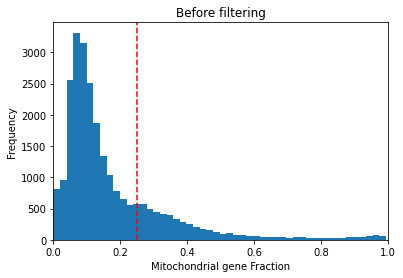

In [14]:
# plot mito fraction for all donors
plt.subplots()
plt.hist(merged_meta['mito_frac'], bins = 50)
plt.axvline(x=0.25, color='red', linestyle='--')
plt.title(str("Before filtering"))
plt.xlabel('Mitochondrial gene Fraction')
plt.ylabel('Frequency')
plt.xlim([0,1])

(0.0, 1.0)

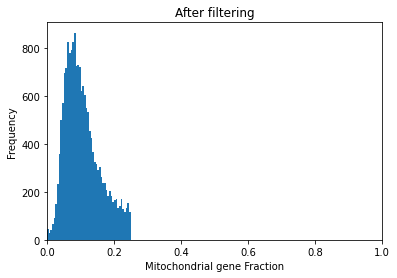

In [15]:
plt.subplots()
plt.hist(merged_Fmeta['mito_frac'], bins = 50)
plt.title(str("After filtering"))
plt.xlabel('Mitochondrial gene Fraction')
plt.ylabel('Frequency')
plt.xlim([0,1])

Text(0, 0.5, 'Frequency')

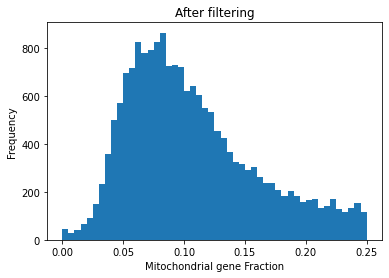

In [16]:
plt.subplots()
plt.hist(merged_Fmeta['mito_frac'], bins = 50)
plt.title(str("After filtering"))
plt.xlabel('Mitochondrial gene Fraction')
plt.ylabel('Frequency')

In [17]:
# Dictionaries of filtered count tables
filtered_matrices = dict()
for key in donors:
    index_list = filtered_meta_dict[key].index
    filtered_matrices[key] = donor_matrices[key].loc[:,index_list]

In [19]:
# Table with number of cells before and after filtering 
filtering_df = pd.DataFrame({'donor': [key for key in donors], 'Ncells_before': [len(donor_matrices[str(key)].columns) for key in donor_matrices]})
filtering_df['Ncells_after'] = [len(filtered_meta_dict[key].index) for key in donors]
filtering_df['Ncells_removed'] = filtering_df['Ncells_before'] - filtering_df['Ncells_after']

filtering_df.sort_values(by=['donor'])



,donor,Ncells_before,Ncells_after,Ncells_removed
88,CAM_R124,30,30,0
109,CAM_R134,91,88,3
45,CAM_R177,31,29,2
13,CAM_R229,49,41,8
108,CAM_R230,609,358,251
...,...,...,...,...
15,XIN_DonorT2D2,83,83,0
49,XIN_DonorT2D3,69,69,0
113,XIN_DonorT2D4,306,306,0
139,XIN_DonorT2D5,174,174,0


In [20]:
# merge count tables into one
matrix = pd.concat((filtered_matrices[key] for key in donors), axis=1, join='outer').fillna(0)
matrix.shape

(59470, 18324)

In [21]:
# file_name = '/Users/twanw/Documents/LUMC/projects/3UTRpancreas/RESULTS/ANALYSIS/SmartseqPancreas_filtered_count_matrix.csv'
file_name = 'SmartseqPancreas_filtered_count_matrix.v2.csv'
# matrix.to_csv(file_name, sep=',')

In [22]:
matrix_unfiltered = pd.concat((donor_matrices[key] for key in donors), axis=1, join='outer').fillna(0)
matrix_unfiltered.shape

(59470, 25237)

In [23]:
matrix_unfiltered

,HPA_HPAP-093_plateP_10A,HPA_HPAP-093_plateP_10B,HPA_HPAP-093_plateP_10D,HPA_HPAP-093_plateP_10E,HPA_HPAP-093_plateP_10F,HPA_HPAP-093_plateP_10G,HPA_HPAP-093_plateP_10H,HPA_HPAP-093_plateP_11A,HPA_HPAP-093_plateP_11B,HPA_HPAP-093_plateP_11D,...,CAM_R231_1001200603_G3,CAM_R231_1001200603_G4,CAM_R231_1001200603_G5,CAM_R231_1001200603_G6,CAM_R231_1001200603_H1,CAM_R231_1001200603_H2,CAM_R231_1001200603_H3,CAM_R231_1001200603_H4,CAM_R231_1001200603_H5,CAM_R231_1001200603_H6
Geneid>Chr,,,,,,,,,,,,,,,,,,,,,
DDX11L1>1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WASH7P>1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MIR6859-1>1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MIR1302-2HG>1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MIR1302-2>1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC233755.2>KI270726.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AC233755.1>KI270726.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AC240274.1>KI270711.1,0,11,0,0,0,0,0,0,0,4,...,0,15,0,0,0,1,0,0,5,16


Text(0.5, 1.0, 'After filtering')

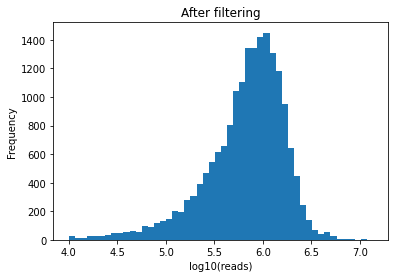

In [24]:
# Number of reads per cell
plt.hist(np.log10(matrix.sum()), bins = 50)
plt.xlabel('log10(reads)')
plt.ylabel('Frequency')
plt.title('After filtering')


Text(0.5, 1.0, 'Before filtering')

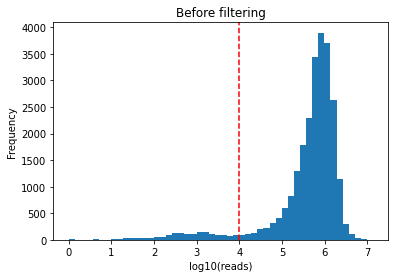

In [25]:
plt.hist(np.log10(matrix_unfiltered.sum()+1), bins = 50)
plt.axvline(x=4.0, color='red', linestyle='--')
plt.xlabel('log10(reads)')
plt.ylabel('Frequency')
plt.title('Before filtering')

# Scanpy sc-RNA-seq analyis
Import the filtered matrix as an anndata object and process the data (normalization, dimensional reduction, clustering, etc.)

In [26]:
# del matrix_unfiltered
del filtered_matrices
del meta_dict
del merged_Fmeta
del merged_meta
del donor_matrices

In [27]:
# Generate an AnnData object from the filtered count matrix
adata = sc.AnnData(matrix.transpose())

In [28]:
# append age bin to metadata file
meta = '/Users/twanw/Documents/LUMC/projects/3UTRpancreas/Data_3UTR_project/revisions/eQTL_pipeline/metadata/3UTRpancreas_donor_metadata.v2.csv'
metadata = pd.read_csv(meta, sep=",")
metadata['donor_ID'] = ['_'.join([lib, donor]) for lib, donor in zip(metadata['library_ID'], metadata['donor_ID'])]
metadata.index = metadata['donor_ID']
# age bins
young = 30
middle = 50

metadata['age_bin'] = ['Young' if metadata['age'][i] <=young else 'Middle_aged' if metadata['age'][i] <= middle else 'Old' for i in metadata.index]
metadata

,library_ID,Dataset_ID,donor_ID,Group,Sex,age,BMI,HbA1c,number of cells,exclude,Multiple donors,newDonorID,age_bin
donor_ID,,,,,,,,,,,,,
DAI_R348,DAI,GSE164875,DAI_R348,ND,Female,42,16.4,5.7,35.0,False,False,donor1,Middle_aged
XIN_DonorND2,XIN,GSE81608,XIN_DonorND2,ND,Female,32,19.0,NaN,NaN,False,False,donor2,Middle_aged
DAI_H2289,DAI,GSE164875,DAI_H2289,ND,Female,62,19.1,5.7,31.0,False,False,donor3,Old
CAM_R233,CAM,GSE124772,CAM_R233,ND,Female,76,19.3,6.0,78.0,False,False,donor4,Old
CAM_R237,CAM,GSE124769,CAM_R237,ND,Male,61,19.6,5.9,59.0,False,False,donor5,Old
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CAM_R256,CAM,GSE124757,CAM_R256,ND,Male,23,32.5,5.4,434.0,False,False,donor121,Young
CAM_R257,CAM,GSE124758,CAM_R257,T2D,Male,56,30.2,7.3,412.0,False,False,donor122,Old
CAM_R259,CAM,GSE124759,CAM_R259,T2D,Female,45,33.1,6.4,412.0,False,False,donor123,Middle_aged


In [29]:
adata.obs

""
HPA_HPAP-093_plateP_10A
HPA_HPAP-093_plateP_10B
HPA_HPAP-093_plateP_10D
HPA_HPAP-093_plateP_10E
HPA_HPAP-093_plateP_10F
...
CAM_R231_1001200603_H2
CAM_R231_1001200603_H3
CAM_R231_1001200603_H4
CAM_R231_1001200603_H5


In [30]:
# Append metadata to the adata 
adata.obs['Donor'] = [str(i.rsplit('_')[0]+"_"+i.rsplit('_')[1]) for i in adata.obs.index]
adata.obs['Dataset'] = [str(i.rsplit('_')[0]) for i in adata.obs.index]
adata.obs['Group'] = [metadata['Group'][i] for i in adata.obs['Donor']]
adata.obs['Sex'] = ['Male' if metadata['Sex'][i] in 'Male' else 'Female' for i in adata.obs['Donor']]
adata.obs['Age'] = [metadata['age'][i] for i in adata.obs['Donor']]
adata.obs['Age_bin'] = [metadata['age_bin'][i] for i in adata.obs['Donor']]
adata.obs['BMI'] = [metadata['BMI'][i] for i in adata.obs['Donor']]
adata.obs['HbA1c'] = [metadata['HbA1c'][i] for i in adata.obs['Donor']]
adata.obs['DonorID'] = [metadata['newDonorID'][i] for i in adata.obs['Donor']]
adata.obs

,Donor,Dataset,Group,Sex,Age,Age_bin,BMI,HbA1c,DonorID
HPA_HPAP-093_plateP_10A,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.980000,4.9,donor89
HPA_HPAP-093_plateP_10B,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.980000,4.9,donor89
HPA_HPAP-093_plateP_10D,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.980000,4.9,donor89
HPA_HPAP-093_plateP_10E,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.980000,4.9,donor89
HPA_HPAP-093_plateP_10F,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.980000,4.9,donor89
...,...,...,...,...,...,...,...,...,...
CAM_R231_1001200603_H2,CAM_R231,CAM,T2D,Female,41,Middle_aged,37.128028,6.8,donor113
CAM_R231_1001200603_H3,CAM_R231,CAM,T2D,Female,41,Middle_aged,37.128028,6.8,donor113
CAM_R231_1001200603_H4,CAM_R231,CAM,T2D,Female,41,Middle_aged,37.128028,6.8,donor113
CAM_R231_1001200603_H5,CAM_R231,CAM,T2D,Female,41,Middle_aged,37.128028,6.8,donor113


In [31]:
adata.var

""
Geneid>Chr
DDX11L1>1
WASH7P>1
MIR6859-1>1
MIR1302-2HG>1
MIR1302-2>1
...
AC233755.2>KI270726.1
AC233755.1>KI270726.1
AC240274.1>KI270711.1


In [32]:
# Remove chromosome from gene name and add to own column
genes_chr = adata.var.index
adata.var['Chr'] = [i.rsplit('>')[1] for i in genes_chr]
adata.var.index = [i.rsplit('>')[0] for i in genes_chr]

In [33]:
# Add biotype to gene
btype='/Users/twanw/Documents/LUMC/projects/3UTRpancreas/RESULTS/ANALYSIS/gff2_gene-name_biotype.txt'
biotype = pd.read_csv(btype, sep=";", names=['gene', 'biotype'], index_col=0)
adata.var['Biotype'] = [biotype['biotype'][i] for i in adata.var.index]

In [34]:
adata.var

,Chr,Biotype
DDX11L1,1,transcribed_unprocessed_pseudogene
WASH7P,1,unprocessed_pseudogene
MIR6859-1,1,miRNA
MIR1302-2HG,1,lncRNA
MIR1302-2,1,miRNA
...,...,...
AC233755.2,KI270726.1,protein_coding
AC233755.1,KI270726.1,protein_coding
AC240274.1,KI270711.1,protein_coding
AC213203.2,KI270713.1,protein_coding


# Processing the datasets

In [35]:
#  Setting the parameters for Scanpy (a library for the analysis of sc RNA seq datasets)

sc.settings.verbosity = 3
sc.logging.print_header()
 

scanpy==1.9.3 anndata==0.9.2 umap==0.5.1 numpy==1.23.3 scipy==1.10.1 pandas==1.5.1 scikit-learn==1.2.2 statsmodels==0.14.1 python-igraph==0.11.5 pynndescent==0.5.2


normalizing counts per cell
    finished (0:00:43)


/Users/twanw/anaconda3/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


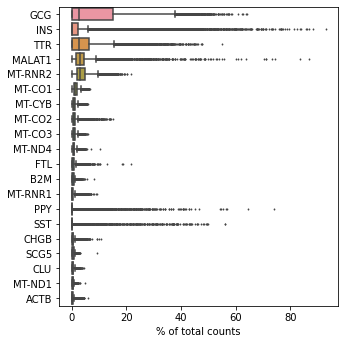

In [36]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [37]:
# Remove genes that are present in less than 3 cells
sc.pp.filter_genes(adata, min_cells=3)

filtered out 4244 genes that are detected in less than 3 cells


In [38]:
adata.var

,Chr,Biotype,n_cells
DDX11L1,1,transcribed_unprocessed_pseudogene,10
WASH7P,1,unprocessed_pseudogene,127
MIR6859-1,1,miRNA,80
MIR1302-2HG,1,lncRNA,5
OR4G4P,1,unprocessed_pseudogene,12
...,...,...,...
AC004556.3,KI270721.1,protein_coding,1661
AC233755.2,KI270726.1,protein_coding,6
AC233755.1,KI270726.1,protein_coding,4
AC240274.1,KI270711.1,protein_coding,4028


In [39]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

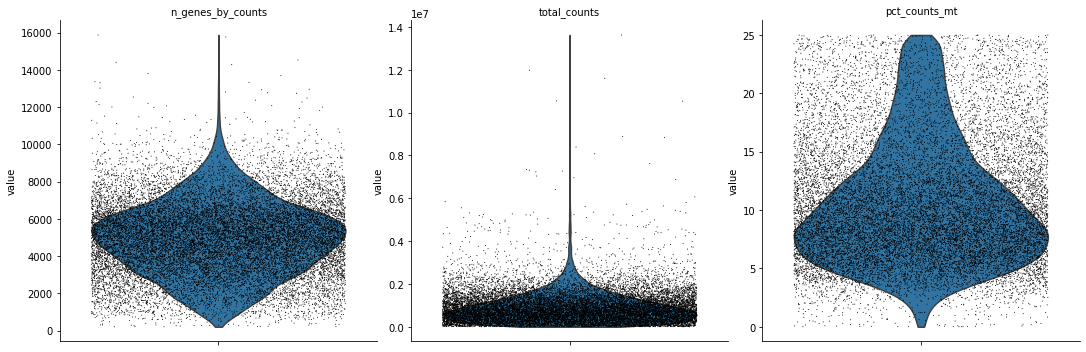

In [40]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

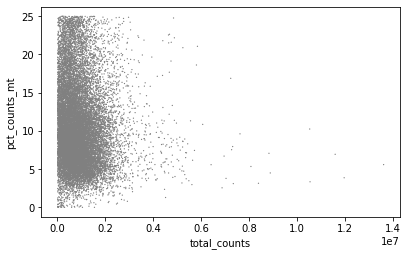

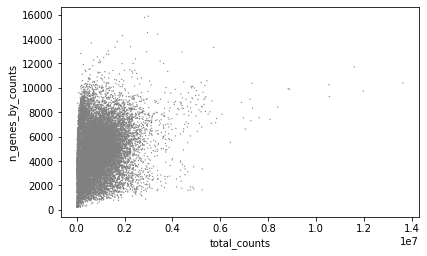

In [41]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [42]:
print(adata.obs.shape)
print(adata.obs.shape)

(18324, 13)
(18324, 13)


# Doublet removal

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.70
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 3.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.5%
Elapsed time: 100.5 seconds


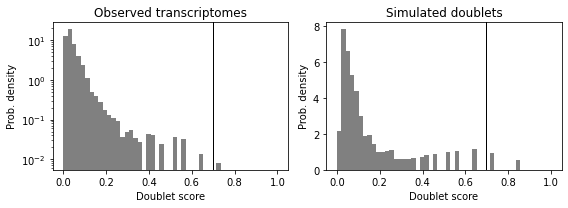

In [43]:
import scrublet as scr
import matplotlib.pyplot as plt

counts_matrix = adata.X.copy() 

# initialize Scrublet
#   expected_doublet_rate: assume ~5–10% for Smart-Seq2; adjust based on cell loading
scrub = scr.Scrublet(counts_matrix,
                     expected_doublet_rate=0.05,
                     sim_doublet_ratio=2.0)  

# run doublet scoring
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2,
                                                           min_cells=3,
                                                           min_gene_variability_pctl=85,
                                                           n_prin_comps=30)

# visualize score distribution to pick/confirm threshold
_ = scrub.plot_histogram()  
plt.show()

In [44]:
# add scores & calls to adata.obs
adata.obs["doublet_score"]      = doublet_scores
adata.obs["predicted_doublet"]  = predicted_doublets

# how many doublets?
print(f"Predicted doublets: {predicted_doublets.sum()} / {len(predicted_doublets)}")

Predicted doublets: 3 / 18324


In [45]:
doublet_treshold = 0.3
adata = adata[adata.obs.doublet_score <= doublet_treshold].copy()

# Normalize and logartithmize the data

In [46]:
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (1:29:09)


In [47]:
sc.pp.log1p(adata)
adata.uns['log1p']['base'] = np.e

## Identify highly variable genes

In [48]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

extracting highly variable genes
    finished (0:00:33)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


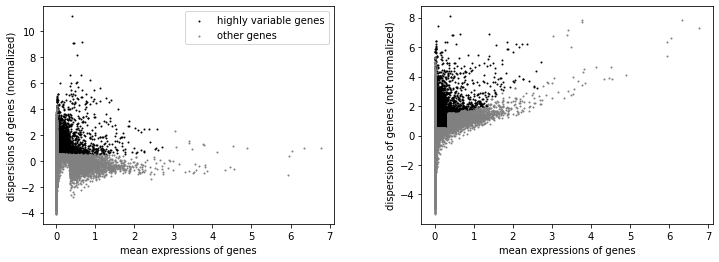

In [49]:
sc.pl.highly_variable_genes(adata)

In [50]:
adata.raw = adata.copy()

In [51]:
adata = adata[:, adata.var.highly_variable]

In [52]:
# Make metadata categorical to use for regression
adata.obs['Sex'] = adata.obs['Sex'].astype('category')
adata.obs['Age_bin'] = adata.obs['Age_bin'].astype('category')
adata.obs['Dataset'] = adata.obs['Dataset'].astype('category')

<ipython-input-52-b69bd4579e59>:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['Sex'] = adata.obs['Sex'].astype('category')


In [53]:
STARindex_file = '/Users/twanw/Documents/LUMC/projects/3UTRpancreas/Data_3UTR_project/revisions/mapping/STARindex.csv'

df_index = pd.read_csv(STARindex_file, index_col=0)
df_index.index = df_index['donor']

adata.obs['STARindex'] = [float(df_index.loc[donor,'STAR_index']) for donor in adata.obs.Donor]
adata.obs['read_length'] = [float(df_index.loc[donor,'read_length']) for donor in adata.obs.Donor]

In [54]:
sc.pp.regress_out(adata, ['total_counts'])
sc.pp.regress_out(adata, ['pct_counts_mt'])
sc.pp.regress_out(adata, ['Dataset'])
sc.pp.regress_out(adata, ['STARindex'])

regressing out ['total_counts']
    finished (0:02:28)
regressing out ['pct_counts_mt']
    finished (0:01:33)
regressing out ['Dataset']
    finished (0:02:12)
regressing out ['STARindex']
    finished (0:01:39)


In [55]:
sc.pp.scale(adata, max_value=10)

## Principal component analysis

In [56]:
adata_beforepca = adata.copy()

In [57]:
adata = adata_beforepca.copy()

In [58]:
sc.tl.pca(adata, svd_solver='arpack')

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:17)


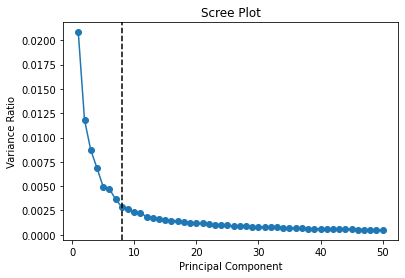

use n_pcs: 8


In [59]:
import matplotlib.pyplot as plt
from kneed import KneeLocator


plt.plot(range(1, len(adata.uns['pca']['variance_ratio']) + 1),
         adata.uns['pca']['variance_ratio'], marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.title('Scree Plot')

var_ratio = adata.uns['pca']['variance_ratio']
x = range(1, len(var_ratio) + 1)

knee = KneeLocator(x, var_ratio, curve='convex', direction='decreasing')

plt.axvline(knee.knee, linestyle='--', color='black')
plt.show()

print(f'use n_pcs: {knee.knee}')

/Users/twanw/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


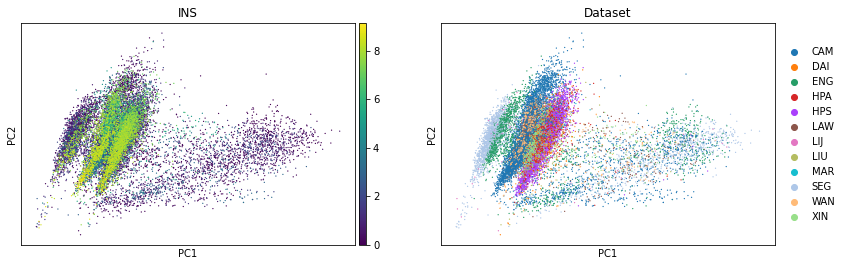

In [60]:
#  Generated PCA scatterplot
sc.pl.pca(adata, color=['INS', 'Dataset'])

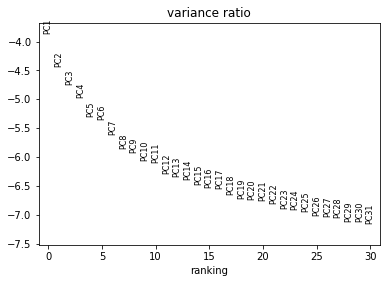

In [61]:
sc.pl.pca_variance_ratio(adata, log=True)

In [62]:
# save data before kNN
adata_beforekNN = adata.copy()

In [63]:
adata = adata_beforekNN.copy()

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:20)
running Leiden clustering
    finished: found 51 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:08)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:13)


/Users/twanw/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/twanw/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


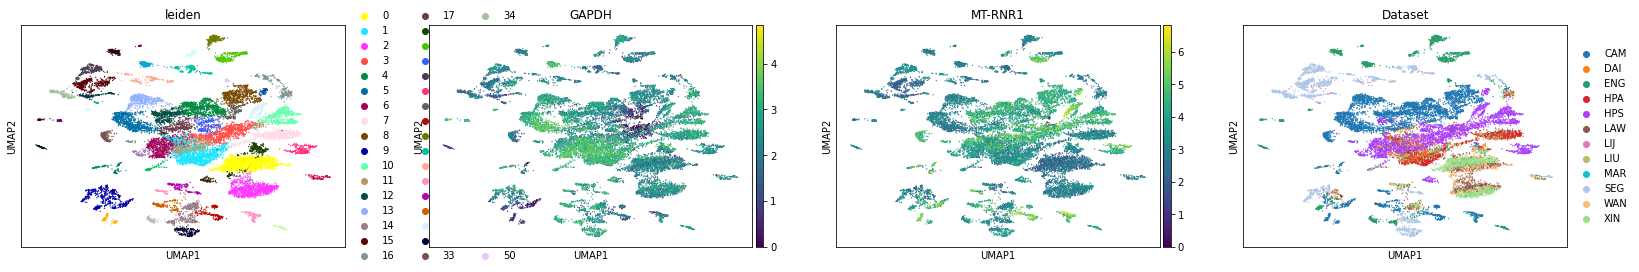

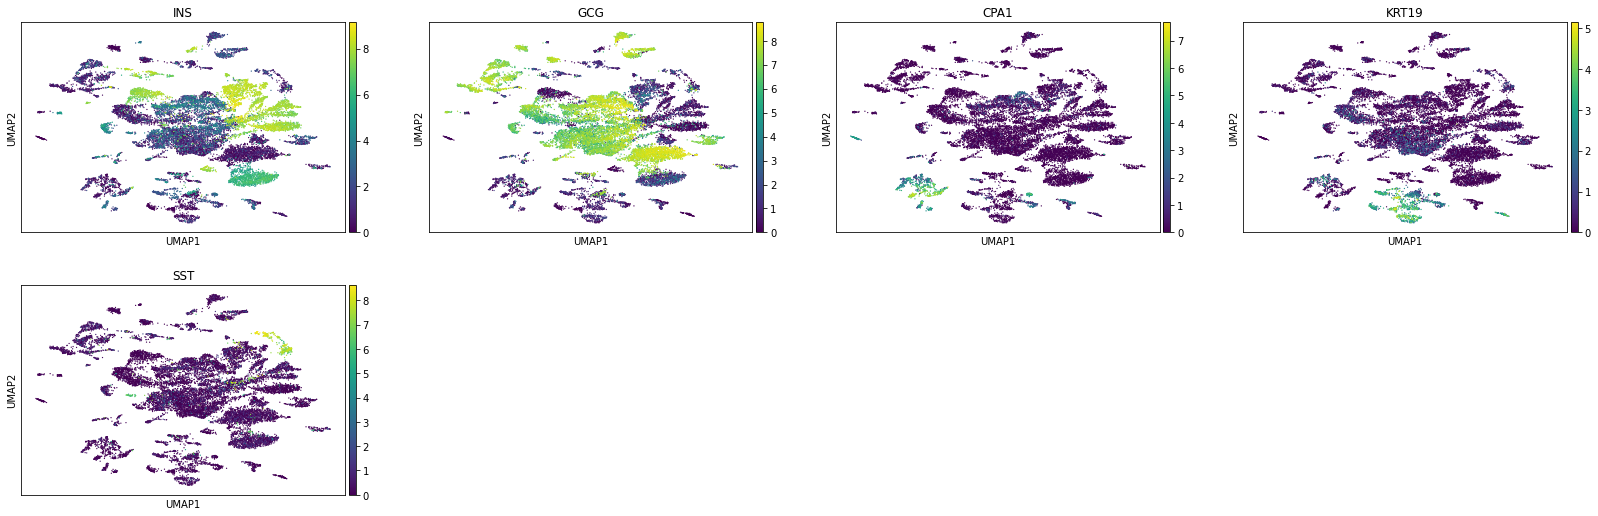

In [64]:
sc.pp.neighbors(adata_beforekNN)
sc.tl.leiden(adata_beforekNN)
sc.tl.umap(adata_beforekNN)
sc.pl.umap(adata_beforekNN, color=['leiden', 'GAPDH', 'MT-RNR1', 'Dataset'])
sc.pl.umap(adata_beforekNN, color=['INS', 'GCG', 'CPA1', 'KRT19', 'SST'])

### Harmony
rerun PCA analysis with harmony to remove dataset influence in the UMAP

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


2025-06-13 22:26:39,541 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-06-13 22:26:43,670 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-06-13 22:26:43,779 - harmonypy - INFO - Iteration 1 of 10
2025-06-13 22:26:48,499 - harmonypy - INFO - Iteration 2 of 10
2025-06-13 22:26:53,084 - harmonypy - INFO - Iteration 3 of 10
2025-06-13 22:26:57,735 - harmonypy - INFO - Iteration 4 of 10
2025-06-13 22:27:02,462 - harmonypy - INFO - Iteration 5 of 10
2025-06-13 22:27:07,099 - harmonypy - INFO - Converged after 5 iterations


k_neighbours 135
leiden_resolution 1.25
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:13)
running Leiden clustering
    finished: found 19 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:01:16)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:18)


/Users/twanw/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/twanw/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


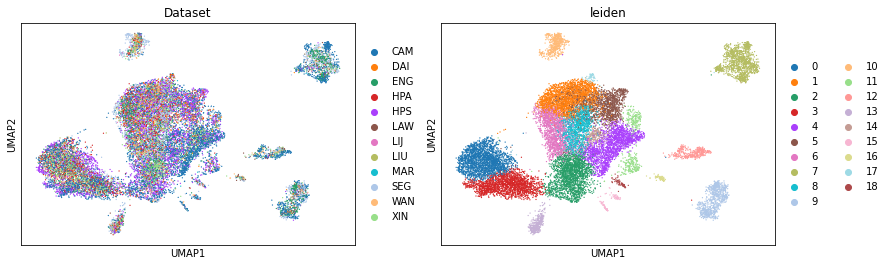

In [65]:
sc.pp.neighbors(adata)
sc.external.pp.harmony_integrate(adata, key='Dataset', random_state=0)

k_neighbours = round(np.sqrt(adata.obs.shape[0]))
leiden_resolution = 1.25
print('k_neighbours', k_neighbours)
print('leiden_resolution', leiden_resolution)

sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_neighbors=k_neighbours, n_pcs=50, random_state=0)
sc.tl.leiden(adata, resolution=leiden_resolution, random_state=0)
sc.tl.umap(adata, random_state=0)
sc.pl.umap(adata, color=['Dataset', 'leiden'])

computing density on 'umap'
--> added
    'umap_density_Dataset', densities (adata.obs)
    'umap_density_Dataset_params', parameter (adata.uns)


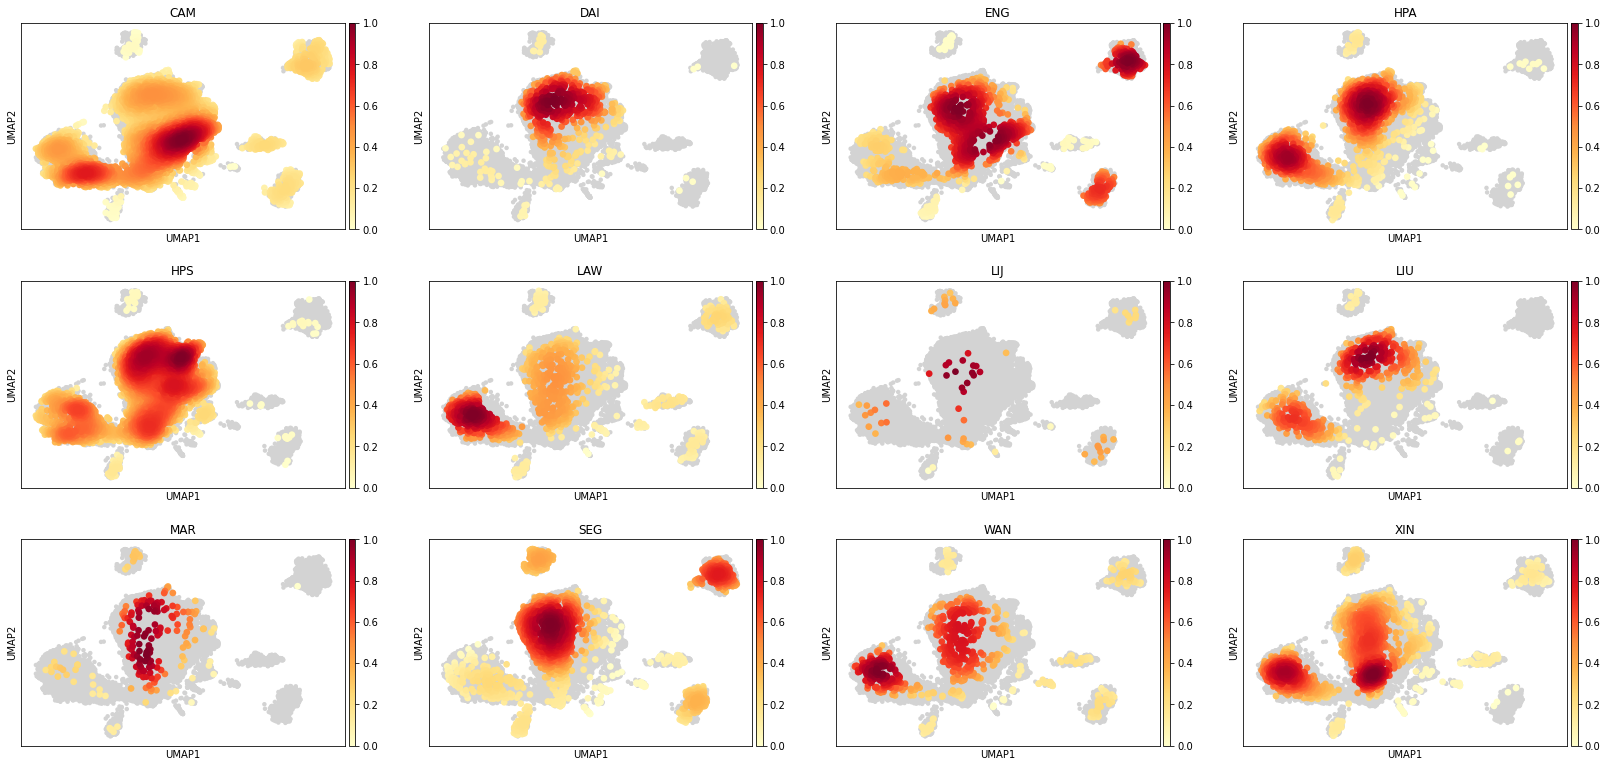

In [66]:
sc.tl.embedding_density(adata, groupby="Dataset")
sc.pl.embedding_density(adata, groupby="Dataset")

computing density on 'umap'
--> added
    'umap_density_Group', densities (adata.obs)
    'umap_density_Group_params', parameter (adata.uns)


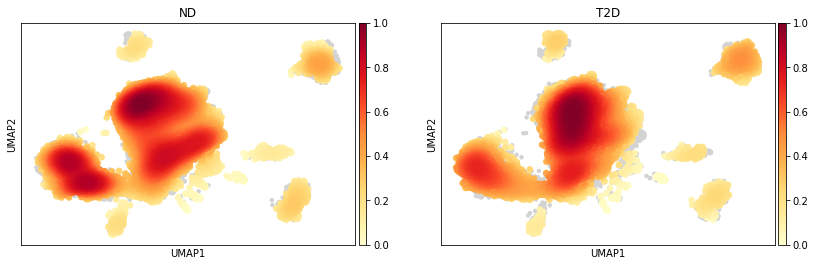

In [67]:
sc.tl.embedding_density(adata, groupby="Group")
sc.pl.embedding_density(adata, groupby="Group")

In [68]:
adata.obs

,Donor,Dataset,Group,Sex,Age,Age_bin,BMI,HbA1c,DonorID,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet,STARindex,read_length,leiden,umap_density_Dataset,umap_density_Group
HPA_HPAP-093_plateP_10A,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.980000,4.9,donor89,4017,317479,43361,13.657911,0.014843,False,99.0,100.0,3,0.568450,0.843057
HPA_HPAP-093_plateP_10B,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.980000,4.9,donor89,5490,487688,50167,10.286700,0.026629,False,99.0,100.0,1,0.897955,0.818999
HPA_HPAP-093_plateP_10D,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.980000,4.9,donor89,4659,483946,44656,9.227476,0.012526,False,99.0,100.0,3,0.363714,0.342068
HPA_HPAP-093_plateP_10E,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.980000,4.9,donor89,7510,863042,86825,10.060345,0.121233,False,99.0,100.0,1,0.970383,0.978628
HPA_HPAP-093_plateP_10F,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.980000,4.9,donor89,4311,629026,101493,16.134945,0.023322,False,99.0,100.0,3,0.514434,0.716857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CAM_R231_1001200603_H2,CAM_R231,CAM,T2D,Female,41,Middle_aged,37.128028,6.8,donor113,7399,2253567,363308,16.121464,0.048641,False,74.0,75.0,3,0.579587,0.583113
CAM_R231_1001200603_H3,CAM_R231,CAM,T2D,Female,41,Middle_aged,37.128028,6.8,donor113,4656,1745218,202318,11.592706,0.036814,False,74.0,75.0,0,0.378273,0.460985
CAM_R231_1001200603_H4,CAM_R231,CAM,T2D,Female,41,Middle_aged,37.128028,6.8,donor113,4656,1362957,168426,12.357396,0.032805,False,74.0,75.0,4,0.639990,0.506841
CAM_R231_1001200603_H5,CAM_R231,CAM,T2D,Female,41,Middle_aged,37.128028,6.8,donor113,7167,1770222,230545,13.023508,0.061532,False,74.0,75.0,0,0.339753,0.398269


# Cell type calling
Based on conventional pancreatic marker genes and cluster and marker genes used in the 10X HPAP paper: https://pmc.ncbi.nlm.nih.gov/articles/PMC9915747/

In [69]:
# adata.uns.setdefault('log1p', {})['base'] = None
# sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
# sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

/Users/twanw/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


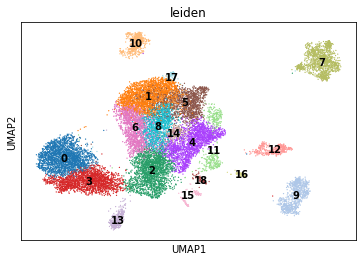

In [70]:
sc.pl.umap(adata, color='leiden', legend_loc='on data')

### beta cells

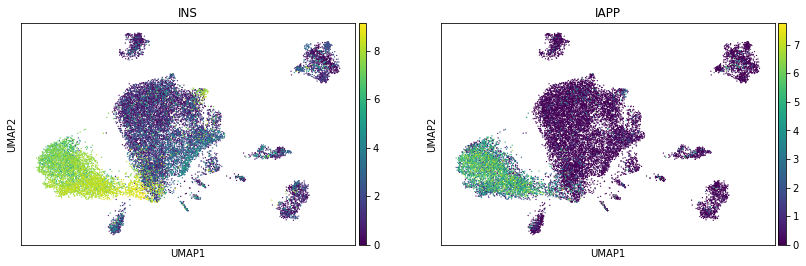

In [71]:
sc.pl.umap(adata, color=['INS','IAPP'])

### alpha cells

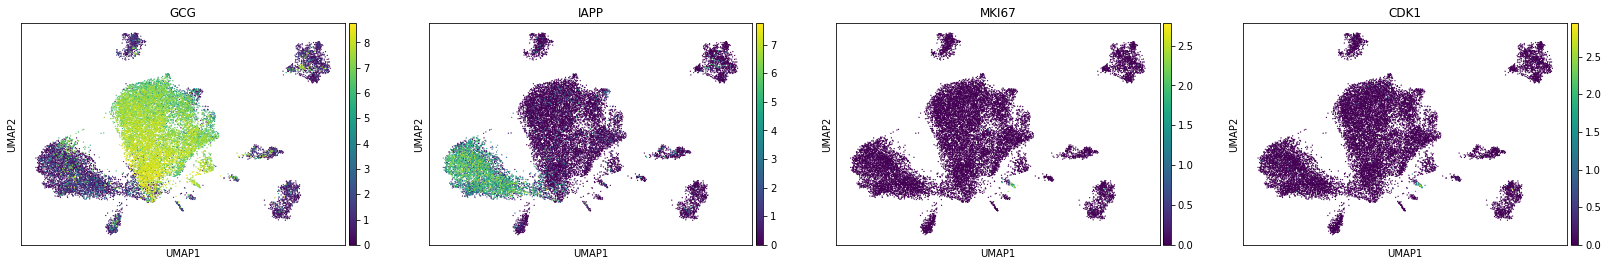

In [72]:
sc.pl.umap(adata, color=['GCG','IAPP', 'MKI67', 'CDK1'])

### delta cells

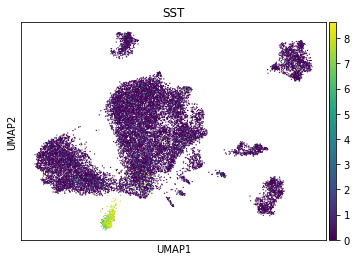

In [73]:
sc.pl.umap(adata, color=['SST'])

### PP cells

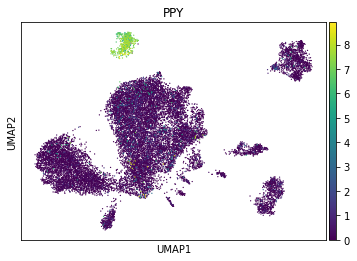

In [74]:
sc.pl.umap(adata, color=['PPY'])

### Ductal cells

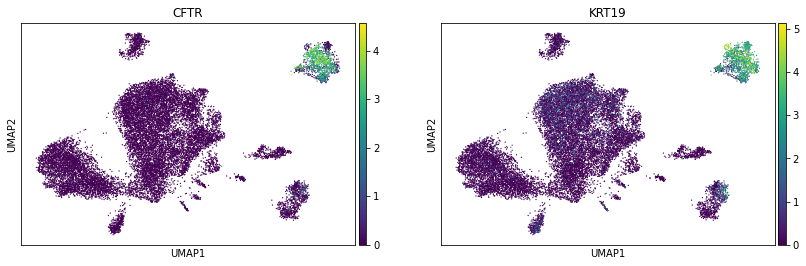

In [75]:
sc.pl.umap(adata, color=['CFTR', 'KRT19'])

### Acinar cells

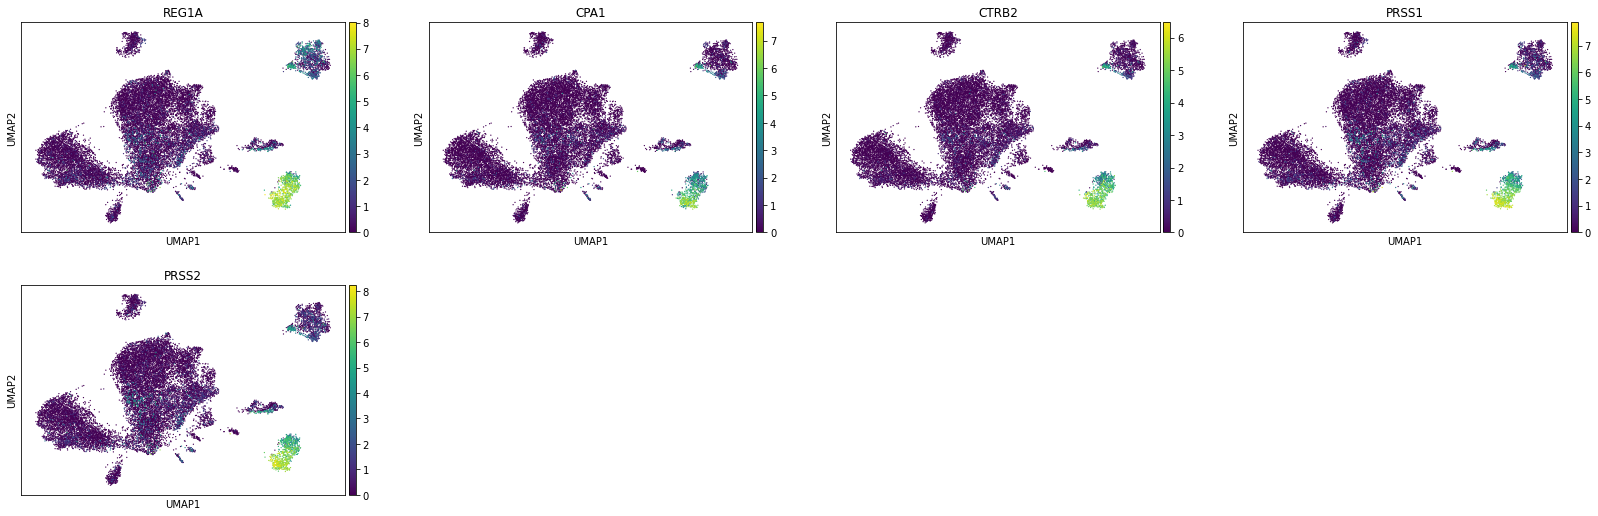

In [76]:
sc.pl.umap(adata, color=['REG1A', 'CPA1', 'CTRB2', 'PRSS1', 'PRSS2'])

### stellate cells

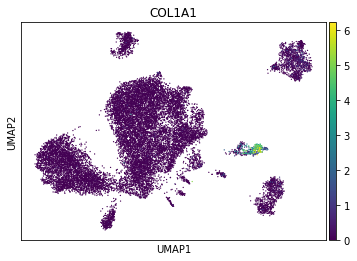

In [77]:
sc.pl.umap(adata, color=['COL1A1'])

### endothelial cells

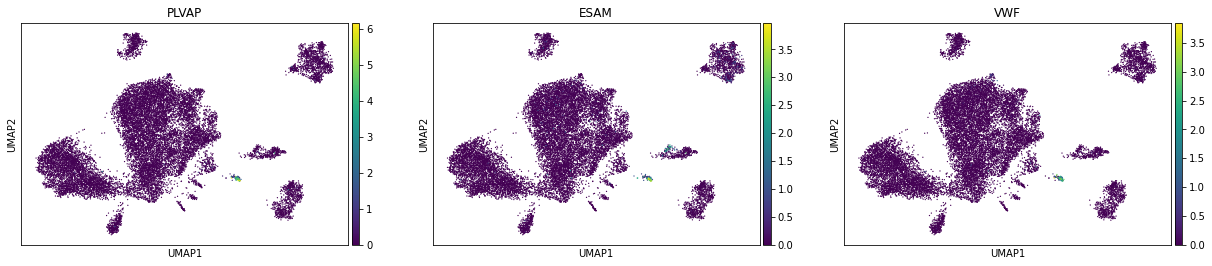

In [78]:
sc.pl.umap(adata, color=['PLVAP', 'ESAM', 'VWF'])

### immune cells

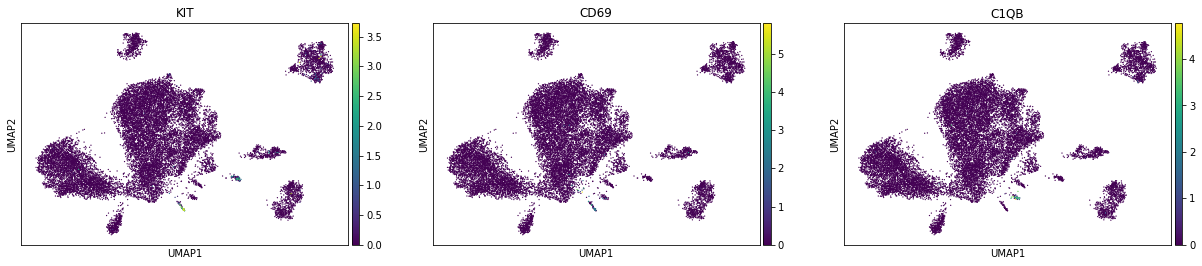

In [79]:
sc.pl.umap(adata, color=['KIT', 'CD69', 'C1QB'])

### Calling

In [80]:
cell_dict = {
    '0': 'beta-cells',
    '1': 'alpha-cells',
    '2': 'alpha/beta-cells',
    '3': 'beta-cells',
    '4': 'alpha-cells',
    '5': 'alpha-cells',
    '6': 'alpha-cells',
    '7': 'ductal-cells',
    '8': 'alpha-cells',
    '9': 'acinar-cells',
    '10': 'PP-cells',
    '11': 'alpha-cells',
    '12': 'stellate-cells',
    '13': 'delta-cells',
    '14': 'alpha-cells',
    '15': 'immune-cells',
    '16': 'endothelial-cells',
    '17': 'alpha-cells',
    '18': 'cycling alpha-cells'
}

adata.obs['Cell_type'] = adata.obs.leiden.apply(lambda x: cell_dict[x])

In [81]:
adata.obs.head()

,Donor,Dataset,Group,Sex,Age,Age_bin,BMI,HbA1c,DonorID,n_genes_by_counts,...,total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet,STARindex,read_length,leiden,umap_density_Dataset,umap_density_Group,Cell_type
HPA_HPAP-093_plateP_10A,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.98,4.9,donor89,4017,...,43361,13.657911,0.014843,False,99.0,100.0,3,0.568450,0.843057,beta-cells
HPA_HPAP-093_plateP_10B,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.98,4.9,donor89,5490,...,50167,10.286700,0.026629,False,99.0,100.0,1,0.897955,0.818999,alpha-cells
HPA_HPAP-093_plateP_10D,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.98,4.9,donor89,4659,...,44656,9.227476,0.012526,False,99.0,100.0,3,0.363714,0.342068,beta-cells
HPA_HPAP-093_plateP_10E,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.98,4.9,donor89,7510,...,86825,10.060345,0.121233,False,99.0,100.0,1,0.970383,0.978628,alpha-cells
HPA_HPAP-093_plateP_10F,HPA_HPAP-093,HPA,ND,Female,50,Middle_aged,34.98,4.9,donor89,4311,...,101493,16.134945,0.023322,False,99.0,100.0,3,0.514434,0.716857,beta-cells


In [ ]:
adata.uns['Cell_type_colors'] = ['#d62728', '#1f77b4', '#8c564b', '#ffbb78', '#e377c2', '#aec7e8', '#b5bd61', '#ff7f0e', '#279e68', '#17becf', '#aa40fc']

/Users/twanw/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


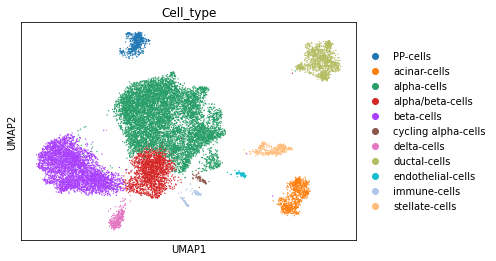

In [82]:
sc.pl.umap(adata, color='Cell_type')

/Users/twanw/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


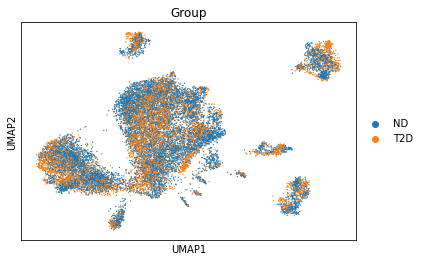

In [83]:
sc.pl.umap(adata, color='Group')

In [84]:
adata.write('../h5ad/islet_eQTL_smartseq.h5ad')